# Heart Disease Prediction
## 1. Dataset Collection & Preparation
This notebook loads the dataset, performs EDA, preprocesses the data, trains multiple models, evaluates them, and performs hyperparameter tuning.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [9]:
# Load the dataset
df = pd.read_csv('heart.csv')
display(df.head())
display(df.info())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


None

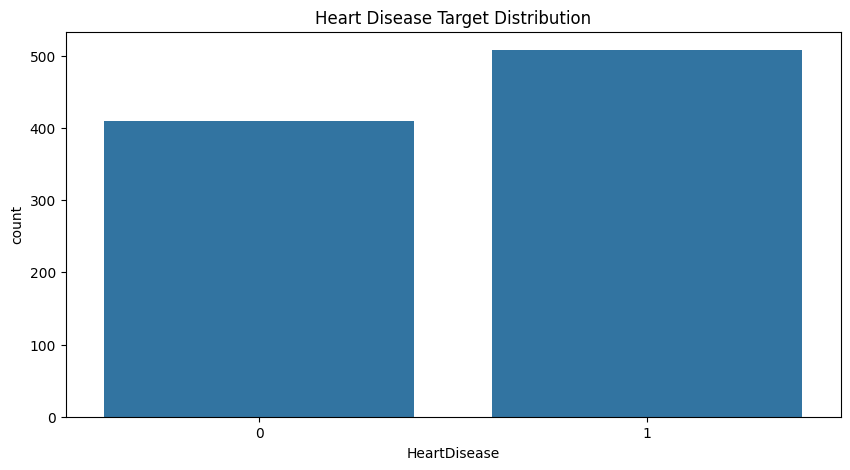

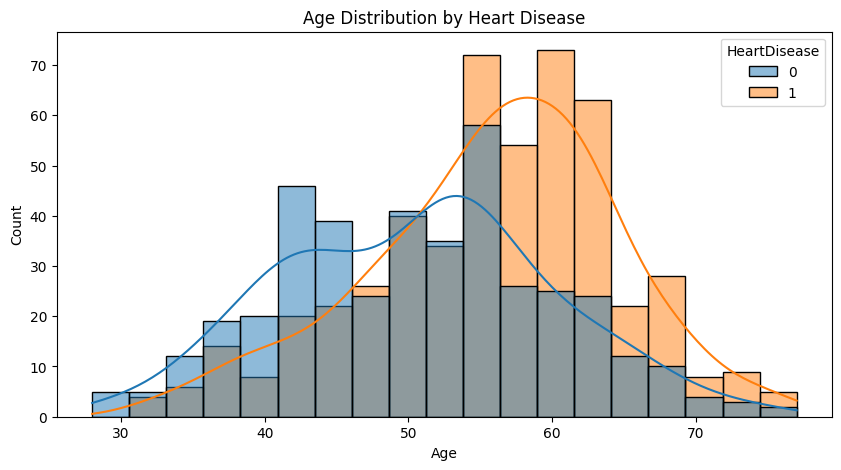

In [10]:
# Exploratory Data Analysis
plt.figure(figsize=(10, 5))
sns.countplot(x='HeartDisease', data=df)
plt.title('Heart Disease Target Distribution')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='HeartDisease', kde=True)
plt.title('Age Distribution by Heart Disease')
plt.show()

In [11]:
# Identify numerical and categorical columns
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Create preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

Training shape: (734, 11), Testing shape: (184, 11)


In [12]:
# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

trained_models = {}
for name, model in models.items():
    # Create pipeline combining preprocessor and model
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    
    # Train
    clf.fit(X_train, y_train)
    trained_models[name] = clf
    
    # Predict & Evaluate
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))

--- Decision Tree ---
F1 Score: 0.8155
              precision    recall  f1-score   support

           0       0.78      0.76      0.77        82
           1       0.81      0.82      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184

--- Random Forest ---
F1 Score: 0.9135
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        82
           1       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184

--- KNN ---
F1 Score: 0.9064
              precision    recall  f1-score   support

           0       0.88      0.89      0.88        82
           1       0.91      0.90      0.91       102

    accuracy                           0.90       184
   macro avg       0.

In [13]:
# Tune Random Forest as it usually performs best
print("Tuning Random Forest...")

param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

# Update trained models with the tuned model
trained_models['Random Forest Tuned'] = grid_search.best_estimator_

# Evaluate tuned model on test set
y_pred_tuned = grid_search.best_estimator_.predict(X_test)
print("--- Random Forest Tuned ---")
print(f"Test F1 Score: {f1_score(y_test, y_pred_tuned):.4f}")

Tuning Random Forest...
Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best Cross-Validation F1 Score: 0.8795
--- Random Forest Tuned ---
Test F1 Score: 0.9187


In [14]:
# Save all models for API deployment
joblib.dump(trained_models['Decision Tree'], 'dt_model.pkl')
joblib.dump(trained_models['Random Forest Tuned'], 'rf_model.pkl')
joblib.dump(trained_models['KNN'], 'knn_model.pkl')

print("Models saved successfully!")

Models saved successfully!
